In [1]:
!pip install --quiet -r requirements.txt

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
DATA_PREPR = Path("./data-sources/pre-processed")
DATA_RAW = Path("./data-sources/raw")

In [5]:
def convertir_txt_data_frame(ruta_path):
    txt_files = list(ruta_path.glob("*.txt"))
    data = []
    for path in txt_files:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            data.append({"text": content})

    df = pd.DataFrame(data)
    return df

In [6]:
temp_cochrane_train_non_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/train/non_pls')
temp_cochrane_train_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/train/pls')
temp_cochrane_test_non_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/test/non_pls')
temp_cochrane_test_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/test/pls')
print(f'Archivos leidos cochrane train non-pls {len(temp_cochrane_train_non_pls)}')
print(f'Archivos leidos cochrane train pls {len(temp_cochrane_train_pls)}')
print(f'Archivos leidos cochrane test non-pls {len(temp_cochrane_test_non_pls)}')
print(f'Archivos leidos cochrane test pls {len(temp_cochrane_test_pls)}')
temp_cochrane_train_non_pls['pls'] = 0
temp_cochrane_train_pls['pls'] = 1
temp_cochrane_test_non_pls['pls'] = 0
temp_cochrane_test_pls['pls'] = 1

Archivos leidos cochrane train non-pls 31118
Archivos leidos cochrane train pls 16241
Archivos leidos cochrane test non-pls 7664
Archivos leidos cochrane test pls 3940


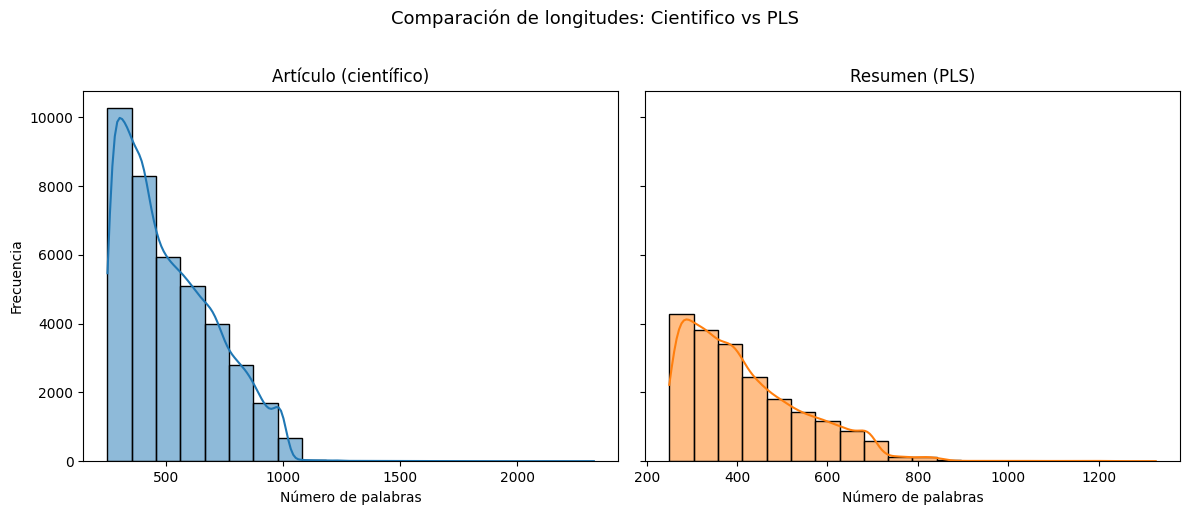

In [7]:
df_temp_cientific = pd.concat([temp_cochrane_train_non_pls['text'],temp_cochrane_test_non_pls['text']],ignore_index=True)
df_temp_pls = pd.concat([temp_cochrane_train_pls['text'],temp_cochrane_test_pls['text']],ignore_index=True)

len_article_words = df_temp_cientific.astype(str).apply(lambda x: len(x.split()))
len_summary_words = df_temp_pls.astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(len_article_words, bins=20, color="tab:blue", ax=axes[0], kde=True)
axes[0].set_title("Artículo (científico)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")

sns.histplot(len_summary_words, bins=20, color="tab:orange", ax=axes[1], kde=True)
axes[1].set_title("Resumen (PLS)")
axes[1].set_xlabel("Número de palabras")

plt.suptitle("Comparación de longitudes: Cientifico vs PLS", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
df_csv = pd.concat([temp_cochrane_train_non_pls,temp_cochrane_train_pls,temp_cochrane_test_non_pls,temp_cochrane_test_pls],ignore_index=True)
rows_per_chunk = 15000
for i, start in enumerate(range(0, len(df_csv), rows_per_chunk), start=1):
    ##Se guarda el dato en bloques para que el archivo resultante sea inferior a 100MB y pueda subirse sin problemas a Github
    df_csv.iloc[start:start+rows_per_chunk].to_csv(f"{DATA_PREPR}/data_chunk_{i}.csv", index=False)

In [8]:
def convertir_txt_data_frame_test(ruta_path,tipo):
    txt_files = list(ruta_path.glob("*.txt"))
    data = []
    for path in txt_files:

        if 'accumulated' in path.stem.lower():
            continue

        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            name_clean = path.stem
            name_clean = name_clean.replace('-abstract', '').replace('-pls', '')
            name_clean = name_clean.strip()
            content = f.read().strip()
            data.append({"name":name_clean,tipo: content})

    df = pd.DataFrame(data)
    return df


temp_cochrane_train_non_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/train/non_pls','article')
temp_cochrane_train_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/train/pls','summary')
temp_cochrane_test_non_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/test/non_pls','article')
temp_cochrane_test_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/test/pls','summary')

def combinar_datasets_por_name(*dfs):
    df_final = dfs[0]
    for df in dfs[1:]:
        df_final = pd.merge(df_final, df, on='name', how='inner')
    return df_final

cochrane_train = combinar_datasets_por_name(temp_cochrane_train_non_pls, temp_cochrane_train_pls)
cochrane_test = combinar_datasets_por_name(temp_cochrane_test_non_pls, temp_cochrane_test_pls)
cochrane_total = pd.concat([cochrane_train, cochrane_test], ignore_index=True)

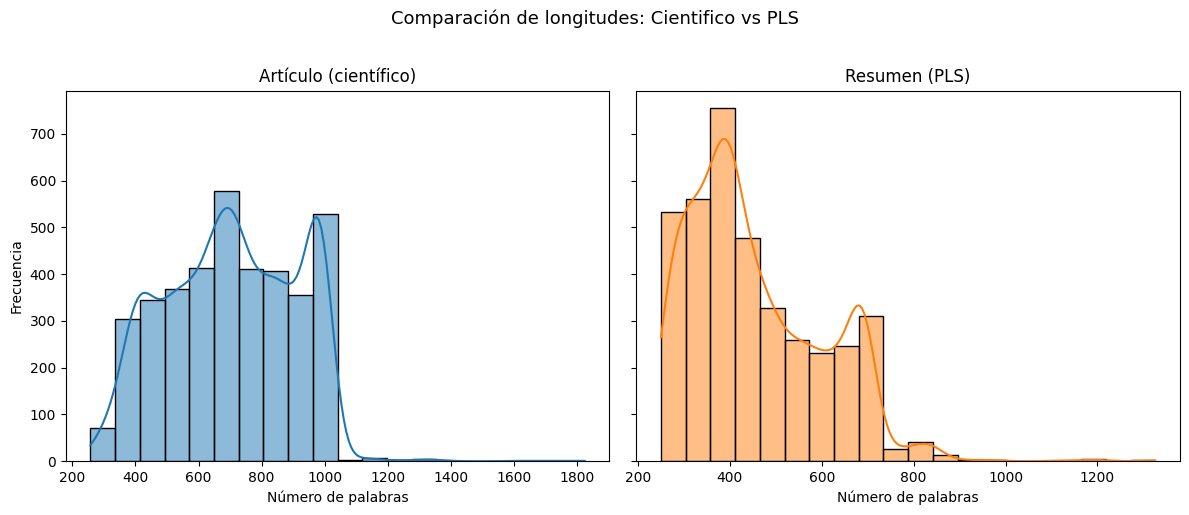

In [ ]:
len_article_words = cochrane_total['article'].astype(str).apply(lambda x: len(x.split()))
len_summary_words = cochrane_total['summary'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(len_article_words, bins=20, color="tab:blue", ax=axes[0], kde=True)
axes[0].set_title("Artículo (científico)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")

sns.histplot(len_summary_words, bins=20, color="tab:orange", ax=axes[1], kde=True)
axes[1].set_title("Resumen (PLS)")
axes[1].set_xlabel("Número de palabras")

plt.suptitle("Comparación de longitudes: Cientifico vs PLS", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
mask = cochrane_total['article'].fillna('').astype(str).apply(lambda x: len(x.split())) <= 2000

df_limit = cochrane_total.loc[mask].reset_index(drop=True)

df_train, df_temp = train_test_split(df_limit, test_size=0.2, random_state=42, shuffle=True)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, shuffle=True)

df_train.to_csv(f"{DATA_PREPR}/data_finetuning_train.csv", index=False)
df_val.to_csv(f"{DATA_PREPR}/data_finetuning_val.csv", index=False)
df_test.to_csv(f"{DATA_PREPR}/data_finetuning_test.csv", index=False)

print(f'Registros totales generados para entrenamiento: {len(df_train)}')
print(f'Registros totales generados para validacion: {len(df_val)}')
print(f'Registros totales generados para test: {len(df_test)}')

Registros totales generados para entrenamiento: 3038
Registros totales generados para validacion: 380
Registros totales generados para test: 380
